In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Environment ready")
print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

Matplotlib is building the font cache; this may take a moment.


Environment ready
OpenCV version: 5.0.0
NumPy version: 2.4.6
Pandas version: 3.0.5


In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATASET_ROOT = PROJECT_ROOT / "data" / "raw" / "PCB_DATASET"

IMAGE_ROOT = DATASET_ROOT / "Images"
ANNOTATION_ROOT = DATASET_ROOT / "Annotations"
TEMPLATE_ROOT = DATASET_ROOT / "PCB_USED"
ROTATION_ROOT = DATASET_ROOT / "rotation"

print(DATASET_ROOT.exists())
print(IMAGE_ROOT.exists())
print(ANNOTATION_ROOT.exists())
print(TEMPLATE_ROOT.exists())

True
True
True
True


(1586, 3034, 3)
(1586, 3034, 3)


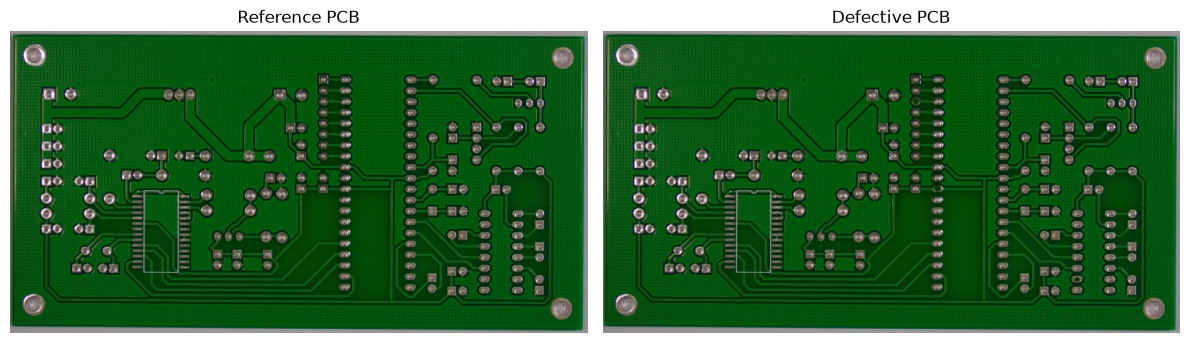

In [2]:
import cv2
import matplotlib.pyplot as plt

defective_path = IMAGE_ROOT / "Missing_hole" / "01_missing_hole_01.jpg"
reference_path = TEMPLATE_ROOT / "01.JPG"

defective = cv2.imread(str(defective_path))
reference = cv2.imread(str(reference_path))

print(defective.shape)
print(reference.shape)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(reference, cv2.COLOR_BGR2RGB))
plt.title("Reference PCB")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(defective, cv2.COLOR_BGR2RGB))
plt.title("Defective PCB")
plt.axis("off")

plt.tight_layout()
plt.show()

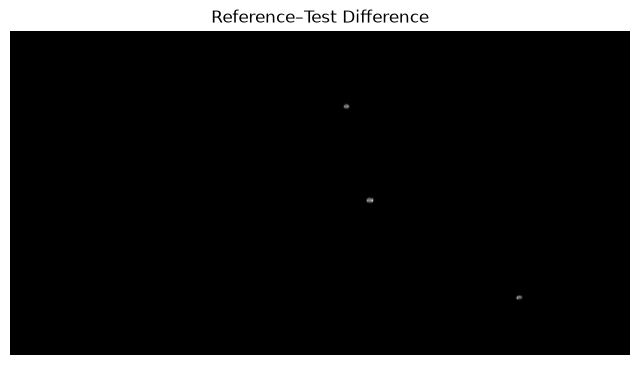

In [3]:
height, width = reference.shape[:2]

defective_resized = cv2.resize(
    defective,
    (width, height),
    interpolation=cv2.INTER_AREA
)

reference_gray = cv2.cvtColor(reference, cv2.COLOR_BGR2GRAY)
defective_gray = cv2.cvtColor(defective_resized, cv2.COLOR_BGR2GRAY)

reference_blur = cv2.GaussianBlur(reference_gray, (5, 5), 0)
defective_blur = cv2.GaussianBlur(defective_gray, (5, 5), 0)

difference = cv2.absdiff(reference_blur, defective_blur)

plt.figure(figsize=(8, 5))
plt.imshow(difference, cmap="gray")
plt.title("Reference–Test Difference")
plt.axis("off")
plt.show()

In [4]:
import xml.etree.ElementTree as ET
from pathlib import Path


def parse_annotation(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    objects = []

    for obj in root.findall("object"):
        box = obj.find("bndbox")

        objects.append({
            "class": obj.findtext("name"),
            "xmin": int(box.findtext("xmin")),
            "ymin": int(box.findtext("ymin")),
            "xmax": int(box.findtext("xmax")),
            "ymax": int(box.findtext("ymax")),
        })

    return objects

annotation_path = (
    ANNOTATION_ROOT
    / "Missing_hole"
    / "01_missing_hole_01.xml"
)

ground_truth_boxes = parse_annotation(annotation_path)

ground_truth_boxes

[{'class': 'missing_hole',
  'xmin': 2459,
  'ymin': 1274,
  'xmax': 2530,
  'ymax': 1329},
 {'class': 'missing_hole',
  'xmin': 1613,
  'ymin': 334,
  'xmax': 1679,
  'ymax': 396},
 {'class': 'missing_hole',
  'xmin': 1726,
  'ymin': 794,
  'xmax': 1797,
  'ymax': 854}]

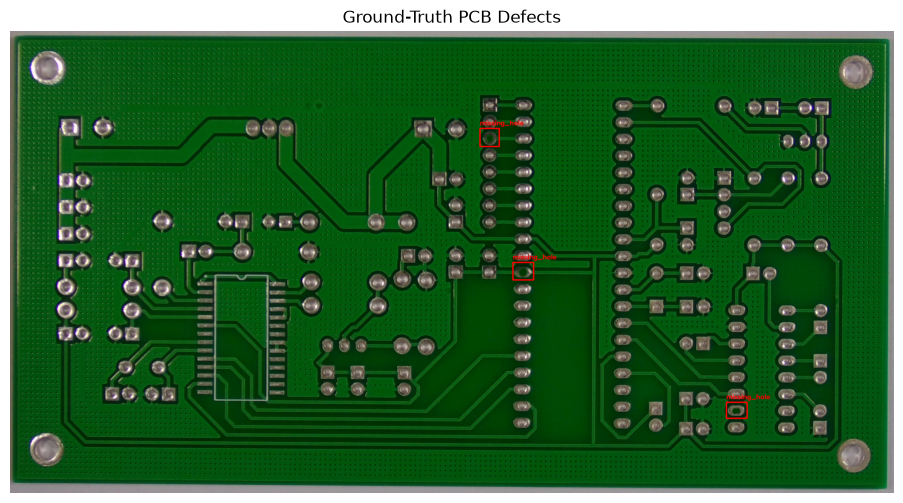

In [5]:
annotated_defective = defective_resized.copy()

for box in ground_truth_boxes:
    cv2.rectangle(
        annotated_defective,
        (box["xmin"], box["ymin"]),
        (box["xmax"], box["ymax"]),
        (0, 0, 255),
        4
    )

    cv2.putText(
        annotated_defective,
        box["class"],
        (box["xmin"], max(30, box["ymin"] - 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 0, 255),
        2
    )

plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(annotated_defective, cv2.COLOR_BGR2RGB))
plt.title("Ground-Truth PCB Defects")
plt.axis("off")
plt.show()

In [7]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from algorithms.common import load_image, preprocess_pair

reference = load_image(reference_path)
defective = load_image(defective_path)

reference_processed, defective_processed, difference = preprocess_pair(
    reference,
    defective
)

print(reference_processed.shape)
print(defective_processed.shape)
print(difference.shape)

(1586, 3034)
(1586, 3034)
(1586, 3034)
